# Création de la base de données

## Les données utilisées

Dans le cadre de ce projet, l'objectif est d'évaluer l'efficacité réelle du Pass Culture. Pour ce faire, nous utilisons différentes bases de données.

In [1]:
import pandas as pd
from functions import *

## Basilic

La Base des lieux et équipements culturels (Basilic) est une base de données réalisée par agrégation de différentes sources : bases de la direction générale des patrimoines et de l’architecture, de la direction générale de la création artistique, de la direction générale des médias et des industries culturelles, de la délégation générale à la transmission, aux territoires et à la démocratie culturelle, du Centre national du cinéma et de l'image animée, du Centre national du livre, du Centre national des arts du cirque, de la rue et du théâtre (Artcena), de la Médiathèque du patrimoine et de la photographie.

Elle porte sur le champ de la France entière, et va nous permettre de trouver toutes les infrastructures culturelles.

#### Importation des données

In [ ]:
# Importation des données

df_brut_basilic = importdata("basilic_29072026.csv", ";")
df_brut_basilic["code_insee"] = df_brut_basilic["code_insee"].astype(str).str.zfill(5)

/home/onyxia/work/Evaluation-Politiques-Publiques-Culturelles/functions.py:14: DtypeWarning: Columns (3,12,20,21,22,28,31,43) have mixed types. Specify dtype option on import or set low_memory=False.
  return (pd.read_csv(path, sep=separateur_csv, encoding="utf-8"))


DIMENSIONS DU JEU DE DONNÉES
Nombre de lignes    : 86366
Nombre de colonnes  : 54

NOMS DES COLONNES ET TYPES
Nom                                         object
Adresse                                     object
Complement Adresse                         float64
Code Postal                                 object
libelle_geographique                        object
code_insee                                  object
Code Insee Arrondt                          object
Identifiant origine                         object
Type équipement ou lieu                     object
Label et appellation                        object
Région                                      object
Domaine                                     object
Archéologie détail                          object
Adresse postale                             object
Département                                 object
Précision équipement                        object
N_Département                               object
N_Région               

Voici maintenant les informations générales sur la base, préalables au nettoyage.

In [1]:
infosbase(df_brut_basilic)

NameError: name 'infosbase' is not defined

#### Choix des variables

Maintenant, nous allons nettoyer la base, pour ne garder que les variables qui sont pertinentes pour notre sujet.

Ainsi, nous allons garder quelques variables permettant d'identifier l'infrastructure de manière unique ("Nom", "libelle_geographique","Département","Région",  "code_insee", "Type équipement ou lieu","Nombre_ecrans", "Nombre_de_salles_de_theatre").

In [3]:
df_basilic = df_brut_basilic[["Nom", 
    "libelle_geographique",
    "Département",
    "Région",  
    "code_insee", 
    "Type équipement ou lieu",
    "Nombre_ecrans", 
    "Nombre_de_salles_de_theatre"]]

Ensuite, il s'agit de rendre les infrastructures identifiables au niveau du département, qui sera l'unité de notre base de données. Pour ce faire, nous allons ne garder que les deux premiers caractères du code INSEE de la commune, qui correspondent au code INSEE du département.

In [ ]:
df_basilic["code_insee"]=df_basilic["code_insee"][:2]

#### Pivot

Nous allons maintenant transformer la base pour que la granularité ne soit pas au niveau du batiment, mais au niveau du département : nous aurons ainsi une ligne par département, et pour chaque type d'équipement, le nombre d'établissements, et le cas échéant, le nombre total de salles (cinéma, théâtre).

La première étape est de vérifier la colonne à partir de laquelle nous allons compter le nombre de bâtiments.

In [4]:
liste_etablissements=df_basilic["Type équipement ou lieu"].unique()
print(liste_etablissements)

['Monument' 'Bibliothèque' "Centre d'art" 'Centre de création artistique'
 'Cinéma' 'Papeterie et maisons de la presse' 'Centre culturel' 'Scène'
 'Espace protégé' 'Théâtre' 'Musée' 'Centre de création musicale'
 'Conservatoire' "Établissement d'enseignement supérieur" 'Parc et jardin'
 'Librairie' 'Lieu de mémoire' "Service d'archives" 'Lieu archéologique'
 'Opéra']


Maintenant, nous pouvons compter le nombre de bâtiment par ville, pour chaque type et au total.

In [ ]:
# Agrégation par commune
label_dummies = pd.get_dummies(df_basilic["Type équipement ou lieu"])
agg_labels = label_dummies.groupby(df_basilic["code_insee"]).sum()

# Agrégats numériques
agg_numeriques = df_basilic.groupby("code_insee").agg(
    nb_ecrans_total=("Nombre_ecrans", "sum"),
    nb_salles_theatre_total=("Nombre_de_salles_de_theatre", "sum"),
    nb_total_etablissements=("Nom", "count")
)

# Infos communales
group_keys = ["code_insee", "Département", "Région"]
infos_departement = df_basilic[group_keys].drop_duplicates(subset="code_insee").set_index("code_insee")

# Fusion finale
df_departement = infos_departement.join([agg_labels, agg_numeriques]).reset_index()

#### Préparation jointure

On vérifie que l'on a bien une ligne par département. La fonction verifdep permet de faire cette vérification.

In [ ]:
# On commence par renommer les variables pour plus de lisibilité

df_departement = df_departement.rename(columns={
    "Département" : "departement",
    "Région" : "region",
    "Bibliothèque" : "nb_biblio",
    "Centre culturel" : "nb_ctr_cult",
    "Centre d'art": "nb_ctr_art",
    "Centre de création artistique": "nb_ctr_crea_art",
    "Centre de création musicale": "nb_ctr_crea_mus",
    "Cinéma": "nb_cine",
    "Conservatoire": "nb_conserv",
    "Espace protégé": "nb_esp_prot",
    "Librairie": "nb_libr",
    "Lieu archéologique": "nb_lieu_archeo",
    "Lieu de mémoire": "nb_lieu_mem",
    'Monument' : "nb_monum",
    'Papeterie et maisons de la presse' : "nb_papet",
    'Scène' : "nb_scene",
    'Théâtre' : "nb_theatre",
    'Musée' : "nb_musee",
    "Établissement d'enseignement supérieur" : "nb_etab_ens_sup",
    'Parc et jardin' : "nb_parc_jard",
    "Service d'archives" : "nb_serv_arch",
    'Opéra' : "nb_opera"
})

In [ ]:
# On vérifie que la base de données est prête pour la jointure
assert(verifdep(df_departement, "code_insee")==True)
# Informations sur la base de données
infosbase(df_departement)

Une seule ligne par commune : jointure possible
DIMENSIONS DU JEU DE DONNÉES
Nombre de lignes    : 22084
Nombre de colonnes  : 27

NOMS DES COLONNES ET TYPES
code_insee                  object
libelle_geographique        object
departement                 object
region                      object
nb_biblio                    int64
nb_ctr_cult                  int64
nb_ctr_art                   int64
nb_ctr_crea_art              int64
nb_ctr_crea_mus              int64
nb_cine                      int64
nb_conserv                   int64
nb_esp_prot                  int64
nb_libr                      int64
nb_lieu_archeo               int64
nb_lieu_mem                  int64
nb_monum                     int64
nb_musee                     int64
nb_opera                     int64
nb_papet                     int64
nb_parc_jard                 int64
nb_scene                     int64
nb_serv_arch                 int64
nb_theatre                   int64
nb_etab_ens_sup              int64
nb

A ce stade, la base de données recense donc de manière synthétique l'ensemble des équipements disponibles pour chaque département. Nous allons maintenant y ajouter des informations complémentaires telles que des informations démographiques.

## Démographie et âges (INSEE)

Nous importons maintenant la base de données de l'INSEE permettant d'obtenir la population des départements par tranche d'âge de cinq ans et par sexe. Le but sera de joindre cette base avec les données issues de la base Basilic afin d'arriver à obtenir la densité d'équipements culturels par habitant.

#### Importation

Dans un premier temps, nous importons les données. Comme pour la base Basilic, elles ont été téléchargées (le 30 juillet 2026) et stockées localement.

In [ ]:
# Importation des données
df_brut_pop = importdata("DS_RP_TD_POPULATION_AGEHARSEX_PRINC_2023_data.csv", ";")
df_brut_pop = df_brut_pop[
    (df_brut_pop['GEO_OBJECT'] == 'DEP')
]

/home/onyxia/work/Evaluation-Politiques-Publiques-Culturelles/functions.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  return (pd.read_csv(path, sep=separateur_csv, encoding="utf-8"))


#### Pivot

Nous changeons maintenant le format de la base de données afin d'obtenir une ligne par commune.

In [9]:
df_pivot = df_brut_pop.pivot_table(
    index=["GEO"],
    columns="AGE",
    values="OBS_VALUE",
    aggfunc="sum",
    fill_value=0
).reset_index()
df_pivot.columns.name = None


In [10]:
# Nettoyage après le pivot
df_pivot = df_pivot[df_pivot["_T"] != 0]
df_pivot = df_pivot.drop_duplicates()
df_population = df_pivot[["GEO", "Y15T19", "_T"]]

#### Préparation jointure

Une fois le pivot effectué, on commence par renommer les variables.

In [11]:
df_population = df_population.rename(columns={'GEO': 'code_insee', 'Y15T19': 'nb_jeunes', '_T': 'pop_total'})

In [ ]:
# On vérifie que la base de données est prête pour la jointure
assert(verifdep(df_population, "code_insee")==True)
# Informations sur la base de données
infosbase(df_population)

Une seule ligne par commune : jointure possible
DIMENSIONS DU JEU DE DONNÉES
Nombre de lignes    : 34852
Nombre de colonnes  : 3

NOMS DES COLONNES ET TYPES
code_insee     object
nb_jeunes     float64
pop_total     float64
dtype: object


## Revenus et niveau de vie (INSEE - Filosofi)

Nous allons maintenant importer les données de revenu et de niveau de vie qui pourront servir de variables de contrôle ou d'instrument dans l'analyse de l'influence du Pass Culture sur les pratiques culturelles des jeunes.

#### Importation

In [ ]:
df_brut_filosofi = importdata("DS_FILOSOFI_CC_2023_data.csv", ";")
df_filosofi = df_brut_filosofi[
    (df_brut_filosofi["GEO_OBJECT"] == "DEP")
    & (df_brut_filosofi["FILOSOFI_MEASURE"].isin(["MED_SL", "PR_MD60"]))
]
df_filosofi = df_filosofi[[
    "GEO",
    "FILOSOFI_MEASURE",
    "OBS_VALUE"
]]

/home/onyxia/work/Evaluation-Politiques-Publiques-Culturelles/functions.py:14: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  return (pd.read_csv(path, sep=separateur_csv, encoding="utf-8"))


#### Pivot

In [14]:
#on passe d'un format court à un format long avec la fonction pivot
df_filosofi = df_filosofi.pivot_table(
    index="GEO",
    columns="FILOSOFI_MEASURE",
    values="OBS_VALUE"
).reset_index()
df_filosofi.columns.name = None  # nettoie l'attribut résiduel


Maintenant, nous allons préparer la base afin de pouvoir faire une jointure propre. Nous devons vérifier que nous avons bien une ligne par commune.

#### Preparation jointure

In [15]:
df_filosofi = df_filosofi.rename(columns={
    "GEO" : "code_insee",
    "MED_SL" : "rev_median",
    "PR_MD60" : "pauvrete"
})
df_filosofi = df_filosofi.drop_duplicates()
df_filosofi = df_filosofi.groupby('code_insee', as_index=False).first()


In [16]:
assert(verifcom(df_filosofi, 'code_insee')==False)

22 communes sont présentent deux fois dans la base : jointure impossible


In [17]:
infosbase(df_filosofi)

DIMENSIONS DU JEU DE DONNÉES
Nombre de lignes    : 30815
Nombre de colonnes  : 3

NOMS DES COLONNES ET TYPES
code_insee     object
rev_median    float64
pauvrete      float64
dtype: object


## Niveau de diplôme, éducation (INSEE)

Enfin, il s'agit d'importer les données sur le niveau de diplôme des individus, au niveau communal afin de pouvoir le comparer aux autres variables obtenues dans les autres bases de données. On choisit ici de ne garder que les données de l'année 2023.

#### Importation de la base

In [ ]:
# On importe les données pour le niveau communal
df_brut_diplome = importdata("DS_RP_DIPLOMES_PRINC_2023_data.csv", ";")
df_diplome = df_brut_diplome[(df_brut_diplome["GEO_OBJECT"] == "DEP") & (df_brut_diplome["SEX"] == "_T")
& (df_brut_diplome["TIME_PERIOD"] == 2023)]
df_diplome = df_diplome[[
    "GEO",
    "EDUC",
    "OBS_VALUE"
]]

/home/onyxia/work/Evaluation-Politiques-Publiques-Culturelles/functions.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  return (pd.read_csv(path, sep=separateur_csv, encoding="utf-8"))


#### Pivot

In [19]:
#on passe d'un format court à un format long avec la fonction pivot
df_diplome = df_diplome.pivot_table(
    index="GEO",
    columns="EDUC",
    values="OBS_VALUE"
).reset_index()
df_diplome.columns.name = None  # nettoie l'attribut résiduel

In [20]:
df_diplome["aucun_diplome"] = df_diplome["001T100_RP"]
df_diplome["inf_bac"] = df_diplome["200_RP"] + df_diplome["300_RP"] + df_diplome["350T351_RP"]
df_diplome["dipl_sup"] = df_diplome["500_RP"] + df_diplome["500T702_RP"] + df_diplome["600_RP"]
df_diplome["sup_master"] = df_diplome["700_RP"]

In [21]:
df_diplome=df_diplome[["GEO", "aucun_diplome", "inf_bac", "dipl_sup", "sup_master"]]
df_diplome["code_insee"]=df_diplome["GEO"]
df_diplome = df_diplome.drop(["GEO"], axis=1)

#### Transformation variables pourcentage

In [ ]:
df_diplome["pop"] = df_diplome["aucun_diplome"] +  df_diplome["inf_bac"] + df_diplome["dipl_sup"] +  df_diplome["sup_master"]
df_diplome["aucun_diplome"] = df_diplome["aucun_diplome"]/df_diplome["pop"]
df_diplome["inf_bac"] = df_diplome["inf_bac"]/df_diplome["pop"]
df_diplome["dipl_sup"] = df_diplome["dipl_sup"]/df_diplome["pop"]
df_diplome["sup_master"] = df_diplome["sup_master"]/df_diplome["pop"]
df_diplome = df_diplome.drop(["pop"], axis=1)

In [23]:
infosbase(df_diplome)

DIMENSIONS DU JEU DE DONNÉES
Nombre de lignes    : 34858
Nombre de colonnes  : 6

NOMS DES COLONNES ET TYPES
aucun_diplome    float64
inf_bac          float64
dipl_sup         float64
sup_master       float64
code_insee        object
pop              float64
dtype: object


Maintenant, nous allons sélectionner la population qui nous intéresse, et donner à la base un format qui nous permettra de la joindre aux autres bases préparées en amont, en répartissant le niveau d'éducation sur différentes variables (pivot, comme pour les précédentes bases).

In [ ]:
assert(verifdep(df_diplome, "code_insee")==True)

Une seule ligne par commune : jointure possible


## Jointure des bases

Nous pouvons désormais joindre les bases de données afin de créer la base à partir de laquelle nous allons travailler.

Pour ce faire, nous commencerons par joindre les bases présentant les caractéristiques des communes, avant de ne garder que celles ayant des infrastructures de loisir et de culture grâce à la deuxième partie.

In [ ]:
df_final = pd.merge(df_departement, df_population, on='code_insee', how='outer')
df_final = pd.merge(df_final, df_filosofi, on='code_insee', how='outer')
df_final = pd.merge(df_final, df_diplome, on='code_insee', how='outer')


In [26]:
infosbase(df_final)

DIMENSIONS DU JEU DE DONNÉES
Nombre de lignes    : 35006
Nombre de colonnes  : 36

NOMS DES COLONNES ET TYPES
code_insee                  object
libelle_geographique        object
departement                 object
region                      object
nb_biblio                  float64
nb_ctr_cult                float64
nb_ctr_art                 float64
nb_ctr_crea_art            float64
nb_ctr_crea_mus            float64
nb_cine                    float64
nb_conserv                 float64
nb_esp_prot                float64
nb_libr                    float64
nb_lieu_archeo             float64
nb_lieu_mem                float64
nb_monum                   float64
nb_musee                   float64
nb_opera                   float64
nb_papet                   float64
nb_parc_jard               float64
nb_scene                   float64
nb_serv_arch               float64
nb_theatre                 float64
nb_etab_ens_sup            float64
nb_ecrans_total            float64
nb_salles_theat

In [27]:
for elt in ['nb_biblio', 'nb_ctr_cult', 'nb_ctr_art', 'nb_ctr_crea_art', 'nb_ctr_crea_mus', 'nb_cine', 'nb_conserv', 'nb_esp_prot', 'nb_libr', 'nb_lieu_archeo', 'nb_lieu_mem', 'nb_monum', 'nb_musee', 'nb_opera', 'nb_papet', 'nb_parc_jard', 'nb_scene', 'nb_serv_arch', 'nb_theatre', 'nb_etab_ens_sup', 'nb_ecrans_total', 'nb_salles_theatre_total', 'nb_total_etablissements']:
    df_final[elt] = df_final[elt].fillna(0)

<table>
  <caption>
    Variables de la base df_final
  </caption>
  <thead>
    <tr>
      <th scope="col">Nom</th>
      <th scope="col">Type</th>
      <th scope="col">Unité</th>
      <th scope="col">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th scope="row">code_insee</th>
      <td>str</td>
      <td>///</td>
      <td>Code INSEE de la commune</td>
    </tr>
    <tr>
      <th scope="row">libelle_geographique</th>
      <td>str</td>
      <td>///</td>
      <td>Nom de la commune</td>
    </tr>
    <tr>
      <th scope="row">departement</th>
      <td>str</td>
      <td>///</td>
      <td>Département de la commune</td>
    </tr>
    <tr>
      <th scope="row">region</th>
      <td>str</td>
      <td>///</td>
      <td>Région de la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_biblio</th>
      <td>float64</td>
      <td>Nombre</td>
      <td>Nombre de bibliothèques dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_ctr_cul</th>
      <td>float64</td>
      <td>Nombre</td>
      <td>Nombre de centres culturels dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_ctr_art</th>
      <td>float64</td>
      <td>Nombre</td>
      <td>Nombre de centres artistiques dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_ctr_crea_art</th>
      <td>float64</td>
      <td>Nombre</td>
      <td>Nombre de centres de création artistique dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_ctr_crea_mus</th>
      <td>float64</td>
      <td>Nombre</td>
      <td>Nombre de centres de création musicale dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_cine</th>
      <td>float64</td>
      <td>Nombre</td>
      <td>Nombre de cinémas dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_conserv</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_esp_prot</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_libr</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_lieu_archeo</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_lieu_mem</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_monum</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_musee</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_opera</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_papet</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_parc_jard</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_scene</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_serv_arch</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_theatre</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_etab_ens_sup</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_ecrans_total</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_salles_theatre_total</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_total_etablissements</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">nb_jeunes</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">pop_total</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">rev_median</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">pauvrete</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">aucun_diplome</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">inf_bac</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">dipl_sup</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
    <tr>
      <th scope="row">sup_master</th>
      <td>float64</td>
      <td>///</td>
      <td> dans la commune</td>
    </tr>
  </tbody>
</table>

## Statistiques descriptives et visualisation

Couleurs :
Bleu -> Blues 
Rouge -> Reds

0 / 34915
count    34915.000000
mean         2.344551
std          9.687054
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max        554.000000
Name: nb_total_etablissements, dtype: float64


/opt/python/lib/python3.13/site-packages/mapclassify/classifiers.py:1767: UserWarning: Not enough unique values in array to form 10 classes. Setting k to 6.
  self.bins = quantile(y, k=k)


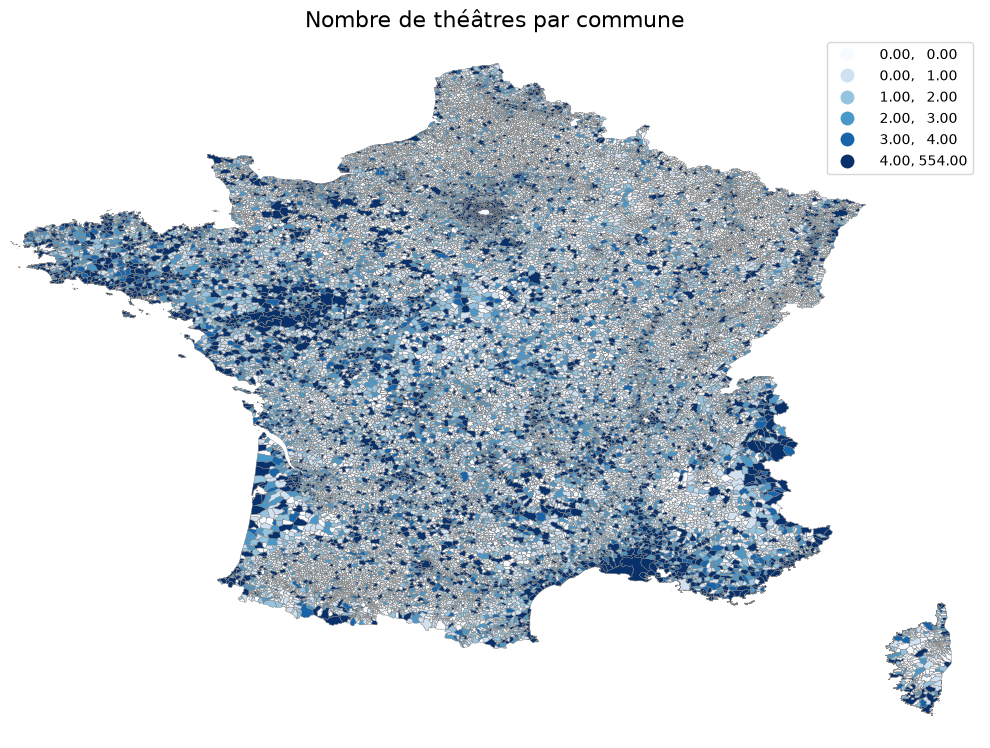

In [33]:
carte_com_cat(df_final, "code_insee", "nb_total_etablissements", "Blues", "Nombre de théâtres par commune")

In [34]:
print(df_final[df_final["nb_total_etablissements"]==554])

      code_insee libelle_geographique departement              region  \
12369      33063             Bordeaux     Gironde  Nouvelle-Aquitaine   

       nb_biblio  nb_ctr_cult  nb_ctr_art  nb_ctr_crea_art  nb_ctr_crea_mus  \
12369       13.0          0.0         2.0              2.0              1.0   

       nb_cine  ...  nb_total_etablissements    nb_jeunes  pop_total  \
12369      5.0  ...                    554.0  78612.08251  1071964.0   

       rev_median  pauvrete  aucun_diplome   inf_bac  dipl_sup  sup_master  \
12369     27590.0      18.9       0.069358  0.196594  0.538088    0.195961   

                pop  
12369  290158.16936  

[1 rows x 36 columns]
